In [166]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
import matplotlib.pyplot as plt
import os
from random import shuffle

In [167]:

def get_data(directory, dirs):

    max_jerks = []
    max_accs = []
    max_vels = []
    max_heights = []

    jerks = []
    accelerations = []
    velocities = []
    heights = []
    timestamps = []

    for filename in dirs:
        if filename.endswith('.csv'):
            file_path = os.path.join(directory, filename)
            
            df = pd.read_csv(file_path)
            
            max_jerk = df['aJerk'].abs().max()
            max_vel = df['aVelocity'].abs().max()
            max_acc = df['aAcc'].max()
            max_height = df['aHeight'].max()

            max_jerks.extend([max_jerk for i in range(len(df))])
            max_accs.extend([max_acc for i in range(len(df))])
            max_vels.extend([max_vel for i in range(len(df))])
            max_heights.extend([max_height for i in range(len(df))])

            jerks.extend(df['aJerk'].abs())
            accelerations.extend(df['aAcc'].abs())
            velocities.extend(df['aVelocity'].abs())
            heights.extend(df['aHeight'].abs())
            timestamps.extend(df['timestamps'])

    data = {
        "max_jerk": max_jerks,
        "max_acc": max_accs,
        "max_vel": max_vels,
        "max_height": max_heights,
        "jerks": jerks,
        "accelerations": accelerations,
        "velocities": velocities,
        "heights": heights,
        "timestamps": timestamps
        }   

    return pd.DataFrame(data)


In [168]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import Ridge
from sklearn.model_selection import KFold, cross_val_score


directory = './lr_data'
dirs = os.listdir(directory)
shuffle(dirs)
test_size = 15
training_df = get_data(directory, dirs[:-test_size])
test_df = get_data(directory, dirs[-test_size:])

import warnings
warnings.filterwarnings("ignore")

predicting = 'accelerations'

if predicting == 'accelerations':
    degree = 7
    power = 1
if predicting == 'velocities':
    degree = 6
    power = 1

print("***MODEL****")
print(f"PREDICITING: {predicting}")
print(f"DEGREE: {degree}")
print(f"POWER: {power}")
# Define the polynomial model with Ridge regression
poly_model = make_pipeline(PolynomialFeatures(degree, include_bias=False), Ridge(alpha=0.85))

# Prepare training features and target variable
features_to_transform = training_df[['max_jerk', 'max_acc', 'max_vel', 'max_height']]
transformed_features = features_to_transform.apply(lambda x: np.power(x, power))

# Combine the transformed features with the timestamps
training_features = pd.concat([training_df['timestamps'], transformed_features], axis=1)

# Apply RFE with the specified number of features
# poly_model = RFE(poly_model, n_features_to_select=3)

# Define the cross-validation strategy: 5-Fold Cross-Validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Perform cross-validation with RFE
cv_scores = cross_val_score(poly_model, training_features, training_df[predicting], cv=kf, scoring='neg_mean_squared_error')

# Convert the negative MSE scores to positive and calculate RMSE
mse_scores = -cv_scores
rmse_scores = np.sqrt(mse_scores)

print("Cross-validated MSE scores: ", mse_scores)
print("Cross-validated RMSE scores: ", rmse_scores)
print("Average RMSE: ", rmse_scores.mean())

# After cross-validation, fit the model on the entire training data
poly_model.fit(training_features, training_df[predicting])

# Prepare test features and make predictions
test_features = test_df[['timestamps', 'max_jerk', 'max_acc', 'max_vel', 'max_height']]
test_features = test_features.apply(lambda x: np.power(x, power))
test_df[f'predicted_{predicting}'] = poly_model.predict(test_features)

# Evaluate the model on the test set
print(f"Test set R^2 score: {poly_model.score(test_features, test_df[predicting])}")


***MODEL****
PREDICITING: accelerations
DEGREE: 7
POWER: 1
Cross-validated MSE scores:  [0.00123279 0.00116543 0.00125256 0.00117916 0.0012036 ]
Cross-validated RMSE scores:  [0.03511113 0.03413842 0.03539146 0.03433883 0.03469297]
Average RMSE:  0.03473455883982106
Test set R^2 score: 0.9928891199975448


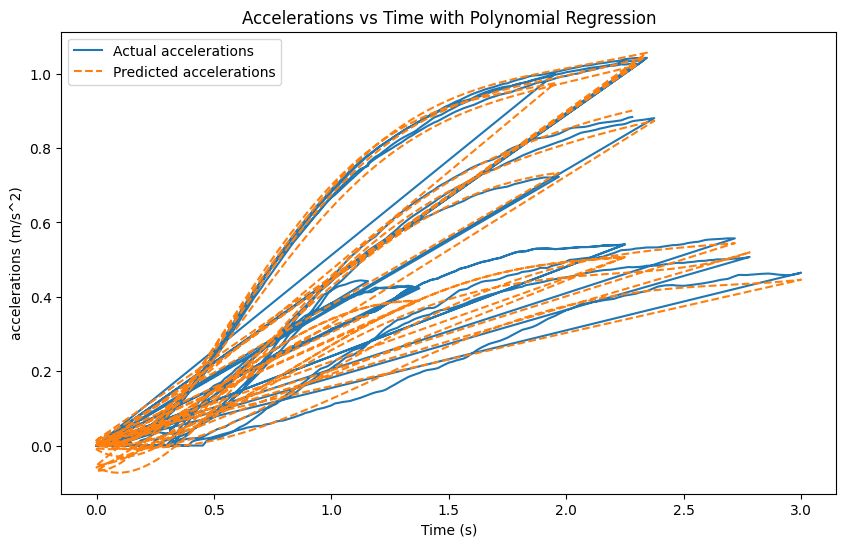

In [169]:
plt.figure(figsize=(10, 6))
plt.plot(test_df['timestamps'], test_df[predicting], label=f'Actual {predicting}')
plt.plot(test_df['timestamps'], test_df[f'predicted_{predicting}'], label=f'Predicted {predicting}', linestyle='--')
plt.xlabel('Time (s)')
plt.ylabel(f'{predicting} (m/s^2)')
plt.legend()
plt.title(f'{predicting.capitalize()} vs Time with Polynomial Regression')
plt.show()

In [170]:
poly_features = poly_model.named_steps['polynomialfeatures']
ridge_model = poly_model.named_steps['ridge']

coefficients = ridge_model.coef_
intercept = ridge_model.intercept_

# Construct the equation
feature_names = poly_features.get_feature_names_out()
equation = f"y = {intercept:.3f}"
for coef, name in zip(coefficients, feature_names):
    equation += f" + {coef:.3f} * {name}"

print("Ridge Regression Model Equation:")
print(equation)

Ridge Regression Model Equation:
y = 0.049 + 0.087 * timestamps + -0.032 * max_jerk + -0.051 * max_acc + -0.290 * max_vel + -0.017 * max_height + -0.066 * timestamps^2 + 0.130 * timestamps max_jerk + 0.370 * timestamps max_acc + -0.287 * timestamps max_vel + 0.068 * timestamps max_height + -0.038 * max_jerk^2 + 0.014 * max_jerk max_acc + -0.213 * max_jerk max_vel + -0.177 * max_jerk max_height + 0.088 * max_acc^2 + 0.136 * max_acc max_vel + 0.026 * max_acc max_height + 0.230 * max_vel^2 + 0.306 * max_vel max_height + 0.017 * max_height^2 + -0.063 * timestamps^3 + 0.284 * timestamps^2 max_jerk + 0.356 * timestamps^2 max_acc + -0.084 * timestamps^2 max_vel + -0.034 * timestamps^2 max_height + 0.007 * timestamps max_jerk^2 + 0.054 * timestamps max_jerk max_acc + -0.393 * timestamps max_jerk max_vel + -0.225 * timestamps max_jerk max_height + 0.133 * timestamps max_acc^2 + -0.051 * timestamps max_acc max_vel + 0.145 * timestamps max_acc max_height + 0.056 * timestamps max_vel^2 + 0.018 * t

In [171]:
import pandas as pd
from matplotlib import pyplot as plt
import os
from random import choice

In [172]:

def get_periods(result_file, buffer=None):
    with open("./results-a/" + result_file, "r") as f:
        df = pd.read_csv(f)

    period_dfs = []
    i = 0
    previous_end = 0
    while i < len(df):

        period = []
        
        # Collect data until aStages is non-zero and there's at least one period element
        while i < len(df) and (df['aStages'].iloc[i] in [1, 3] or not len(period)):
            if df['aStages'].iloc[i] in [1, 3]:
                period.append([
                    df['timestamps'].iloc[i],
                    df['aAcc'].iloc[i],
                    df['aJerk'].iloc[i],
                    df['aVelocity'].iloc[i],
                    df['aHeight'].iloc[i]
                ])
            i += 1

        # If bad data ignore
        if not len(period) or i >= len(df): continue

        # Split this period element into changing acc sections
        upper_threshold = 0.9 * np.abs(np.array(period)[:, 1]).max()

        curr_top = 0
        for j in range(len(period)):
            if abs(curr_top) > 0:
                if abs(curr_top) < abs(period[j][1]):
                    curr_top = period[j][1]
                else:
                    break
            elif abs(period[j][1]) > upper_threshold:
                curr_top = period[j][1]
        
        period1_df = pd.DataFrame(period[:j], columns=['timestamps', 'aAcc', 'aJerk', 'aVelocity', 'aHeight'])

        period = period[::-1]
        curr_top = 0
        for k in range(len(period)):
            if abs(curr_top) > 0:
                if abs(curr_top) < abs(period[k][1]):
                    curr_top = period[k][1]
                else:
                    break
            elif abs(period[k][1]) > upper_threshold:
                curr_top = period[k][1]
        
        corrected_period = period[:k][::-1]
        period2_df = pd.DataFrame(corrected_period, columns=['timestamps', 'aAcc', 'aJerk', 'aVelocity', 'aHeight'])

        # Calculate buffer sizes
        sliced_df = df.iloc[i + 1:]
        next_stage = sliced_df[sliced_df['aStages'].apply(lambda x: x in [1, 3])].index
        next_stage = len(df) - 1 if len(next_stage) == 0 else next_stage[0]

        mid_index = int(((i - len(period2_df)) + (i - len(period) + len(period1_df))) / 2)
        # Right Buffer 1
        period1_df = pd.concat([period1_df, df.iloc[i - len(period) + len(period1_df):min(i - len(period) + len(period1_df) + buffer, mid_index)]], ignore_index=True)

        # Left Buffer 1
        period1_df = pd.concat([df.iloc[max(previous_end, i - len(period) - buffer):i - len(period)], period1_df], ignore_index=True)

        # Left Buffer 2
        period2_df = pd.concat([df.iloc[max(mid_index, i - len(period2_df) - buffer):i - len(period2_df)], period2_df], ignore_index=True)

        # Right Buffer 2
        period2_df = pd.concat([period2_df, df.iloc[i: i + min(buffer, int((next_stage - i) / 2))]], ignore_index=True)

        previous_end = i;

        for period_df in [period1_df, period2_df]:

            period_df["accelerations_direction"] = "up" if period_df['aAcc'].iloc[int((len(period_df) - 1) / 2)] - period_df['aAcc'].iloc[0] > 0 else "down"
            period_df["velocities_direction"] = "up" if period_df['aVelocity'].iloc[len(period_df) - 1] - period_df['aVelocity'].iloc[0] > 0 else "down"
            period_df["heights_direction"] = "up" if period_df['aHeight'].iloc[len(period_df) - 1] - period_df['aHeight'].iloc[0] > 0 else "down"
            period_df["jerk_direction"] = (df['aJerk'].rolling(window=3).sum() / df['aJerk'].rolling(window=3).sum().abs()).fillna(0)

            period_df["start_jerks"] = period_df['aJerk'].iloc[0]
            period_df["start_accelerations"] = period_df['aAcc'].iloc[0]
            period_df["start_velocities"] = period_df['aVelocity'].iloc[0]
            period_df["start_heights"] = period_df['aHeight'].iloc[0]

            period_df['actual_timestamps'] = period_df['timestamps']
            period_df['timestamps'] = period_df['timestamps'] - period_df['timestamps'].iloc[0]

            period_df['aJerk'] = period_df['aJerk'] - period_df['aJerk'].iloc[0]
            period_df['aJerk'] = abs(period_df['aJerk'])
            period_df['aJerk'] = np.where(period_df['aJerk'] < 0.01, 0, period_df['aJerk'])

            period_df['aAcc'] = period_df['aAcc'] - period_df['aAcc'].iloc[0]
            period_df['aAcc'] = abs(period_df['aAcc'])
            period_df['aAcc'] = np.where(period_df['aAcc'].abs() < 0.01, 0, period_df['aAcc'])

            period_df['aVelocity'] = period_df['aVelocity'] - period_df['aVelocity'].iloc[0]
            period_df['aVelocity'] = abs(period_df['aVelocity'])
            period_df['aVelocity'] = np.where(period_df['aVelocity'] < 0.01, 0, period_df['aVelocity'])

            period_df['aHeight'] = period_df['aHeight'] - period_df['aHeight'].iloc[0]
            period_df['aHeight'] = abs(period_df['aHeight'])
            period_df['aHeight'] = np.where(period_df['aHeight'] < 0.01, 0, period_df['aHeight'])
            
            period_dfs.append(period_df)

    return period_dfs


In [173]:
def differentiate(df, u, v, new_name):
    assert u in df.columns, f"DataFrame must include {u}"
    assert v in df.columns, f"DataFrame must include {v}"
    df[new_name] = 0.0

    for i in range(1, len(df)):
        df.at[i, new_name] = df[new_name].iloc[i - 1]
        if df[u].iloc[i] == None or df[u].iloc[i - 1] == None:
            continue
        
        du = df[u].iloc[i] - df[u].iloc[i - 1]
        dv = df[v].iloc[i] - df[v].iloc[i - 1]

        if dv != 0:
            df.at[i, new_name] = du / dv


In [174]:
def integrate(df, u, v, new_name):
    assert u in df.columns, f"DataFrame must include {u}"
    assert v in df.columns, f"DataFrame must include {v}"
    df[new_name] = 0.0

    for i in range(1, len(df)):
        avg_u = (df[u].iloc[i] + df[u].iloc[i - 1]) / 2
        dv = df[v].iloc[i] - df[v].iloc[i - 1]
        
        df.at[i, new_name] = df[new_name].iloc[i - 1] + avg_u * dv

In [175]:
def chart(df, y1, y2):

    label_y1 = y1.replace("a", "Measured ")
    label_y2 = y2.replace("d", "Predicted ")

    plt.figure(figsize=(10, 6))

    plt.plot(df['timestamps'], df[y1], label=label_y1, color='blue')

    plt.plot(df['timestamps'][:len(df[y2])], df[y2], label=label_y2, color='red')

    # Adding titles and labels
    plt.title(f'{label_y1} and {label_y2} vs Timestamps')
    plt.xlabel('Timestamps')
    plt.ylabel(f"{label_y1} & {label_y2}")

    # Display the legend
    plt.legend()

    # Show the plot
    plt.show()

8900261751609891956


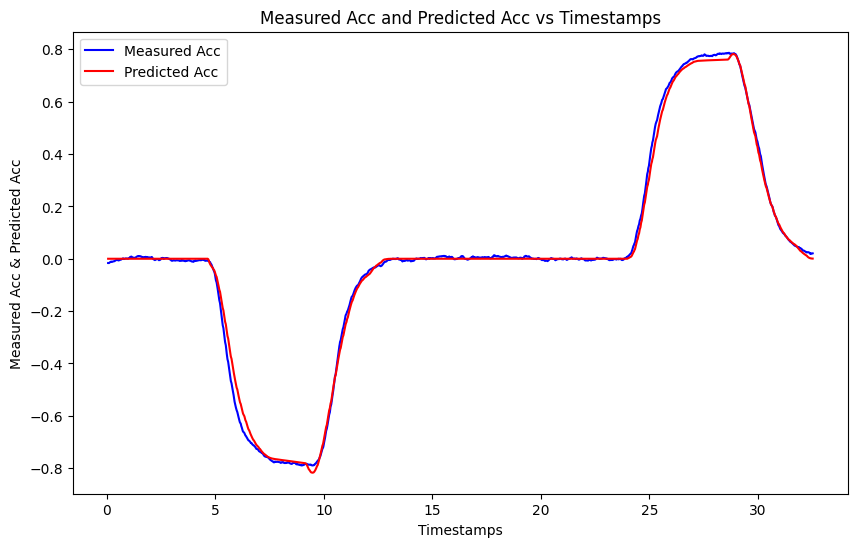

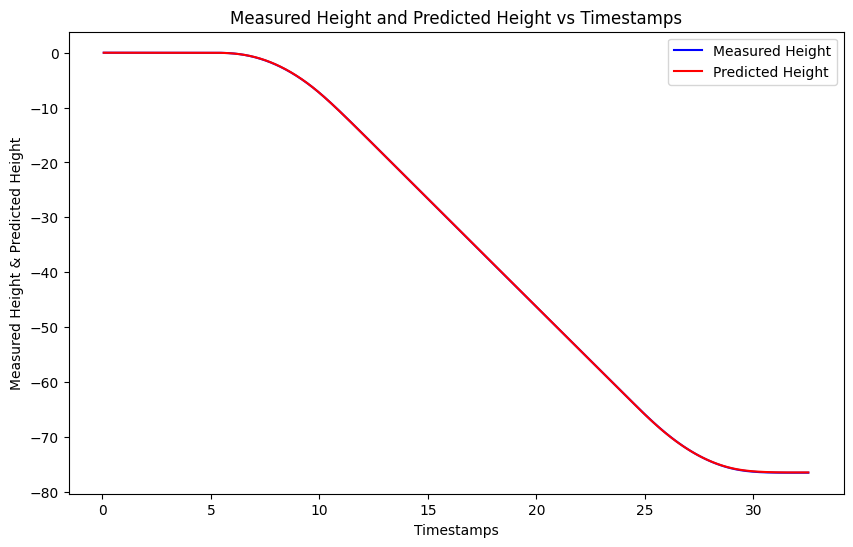

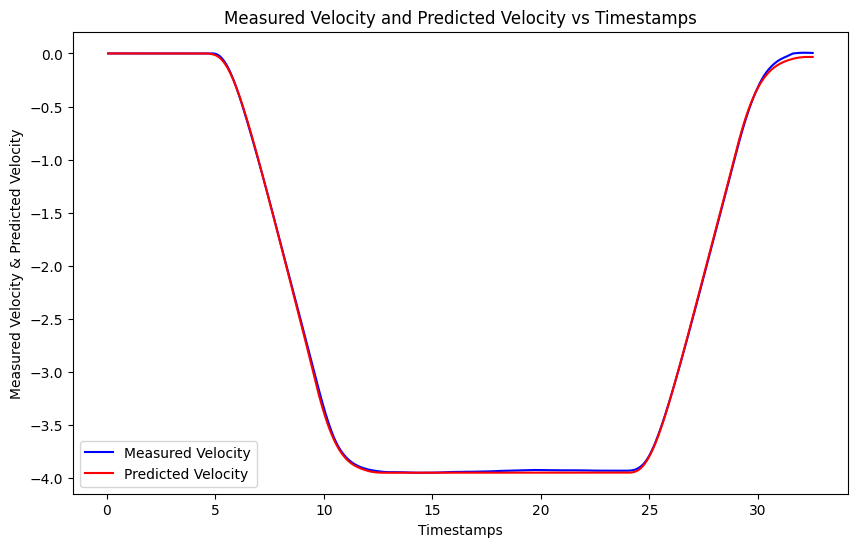

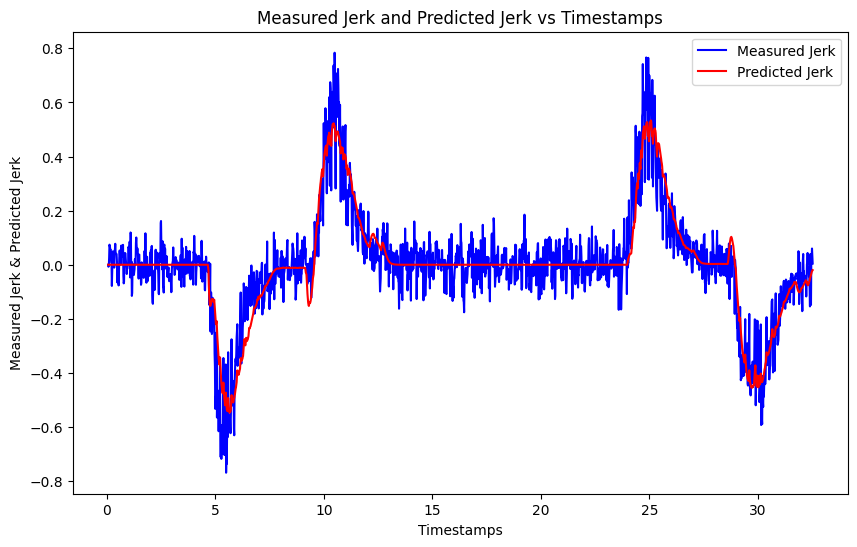

In [176]:

# have predicitng variable
var_map = {
    "heights": "aHeight",
    "accelerations": "aAcc",
    "velocities": "aVelocity",
    "jerks": "aJerk"
}
csv_header = var_map[predicting]

# result_file = "4180432403582521291"
result_file = choice(os.listdir("./results-a"))

df = pd.read_csv(os.path.join("./results-a/", result_file))

df['dAcc'] = 0
df['max_jerk'] = 0
df['max_acc'] = 0
df['max_vel'] = 0
df['max_height'] = 0
df['jerk_direction'] = 0

period_dfs = get_periods(result_file, 20)
previous_index = 0
for index, period_df in enumerate(period_dfs):

    # Calculate j,a,v,d per period
    period_df['max_jerk'] = period_df['aJerk'].abs().max()
    period_df['max_vel'] = period_df['aVelocity'].abs().max()
    period_df['max_acc'] = period_df['aAcc'].abs().max()
    period_df['max_height'] = period_df['aHeight'].abs().max()

    #Get features for model
    draw_features = period_df[['timestamps', 'max_jerk', 'max_acc', 'max_vel', 'max_height']]
    draw_features = draw_features.apply(lambda x: np.power(x, power))

    # Prepare training features and target variable
    features_to_transform = period_df[['max_jerk', 'max_acc', 'max_vel', 'max_height']]
    transformed_features = features_to_transform.apply(lambda x: np.power(x, power))

    # Combine the transformed features with the timestamps
    draw_features = pd.concat([period_df['timestamps'], transformed_features], axis=1)

    #Predict Features
    period_df['dAcc'] = poly_model.predict(draw_features)

    # Flip if its the wrong direction
    if period_df[f'{predicting}_direction'].iloc[0] == "down":
        period_df['dAcc'] *= -1

    # Offset to correct starting value
    period_df['dAcc'] = period_df['dAcc'] + period_df[f'start_{predicting}'].iloc[0]

    # Remove any acceleration values that the model has predicted in the wrong direction
    if period_df['dAcc'].mean() < 0:
        period_df['dAcc'] = np.where(period_df['dAcc'] > 0, 0, period_df['dAcc'])
    else:
        period_df['dAcc'] = np.where(period_df['dAcc'] < 0, 0, period_df['dAcc'])
    
    # Scale to correct value
    max_dAcc = period_df['dAcc'].abs().max()
    max_aAcc = period_df['aAcc'].abs().max()
    # period_df['dAcc'] *= max_aAcc / max_dAcc

    #Attach onto dataframe
    for index, timestamp in enumerate(period_df['actual_timestamps']):
        indecies = df.index[df['timestamps'] == timestamp].tolist()
        df.at[indecies[0], 'dAcc'] = period_df['dAcc'].iloc[index]
        df.at[indecies[0], 'max_jerk'] = period_df['max_jerk'].iloc[0]
        df.at[indecies[0], 'max_acc'] = period_df['max_acc'].iloc[0]
        df.at[indecies[0], 'max_vel'] = period_df['max_vel'].iloc[0]
        df.at[indecies[0], 'max_height'] = period_df['max_height'].iloc[0]
        df.at[indecies[0], 'jerk_direction'] = period_df['jerk_direction'].iloc[index]

    j = indecies[0] + 1
    while j < len(df) and abs(df['dAcc'].iloc[j - 1]) > 0.01 and df['aStages'].iloc[j] in [0, 2]:
        df.at[j, 'dAcc'] = df['dAcc'].iloc[j - 1] * 0.95
        j += 1
    
    # Remove any missing timestamp errors
    for j in range(indecies[0] - len(period_df), indecies[0]):
        if abs(df['dAcc'].iloc[j]) < 0.001:
            df.at[j, 'dAcc'] = df['dAcc'].iloc[j - 1]

    for j in range(indecies[0] - len(period_df), indecies[0]):
        if df['jerk_direction'].iloc[j] not in [1, -1]:
            df.at[j, 'jerk_direction'] = df['jerk_direction'].iloc[j - 1]

    # Fix hill dips due to lack of prediction on acceleration curves
    if abs(df['aAcc'].iloc[previous_index]) > 0.2:
        acc_range = period_df['dAcc'].iloc[0] - df['dAcc'].iloc[previous_index]
        for j in range(previous_index + 1, indecies[0] - len(period_df) + 1):
            df.at[j, 'dAcc'] += (
                df['dAcc'].iloc[previous_index] + acc_range *
                (
                    (df['timestamps'].iloc[j] - df['timestamps'].iloc[previous_index])
                    /
                    (df['timestamps'].iloc[indecies[0] - len(period_df)] - df['timestamps'].iloc[previous_index])
                )
            )
    
    previous_index = indecies[0]


# Integrating to get the vels, and heights
integrate(df, 'dAcc', 'timestamps', 'dVelocity')

# This is the only correction truly needed on this model
max_dVelocity = df['dVelocity'].abs().max()
max_aVelocity = df['aVelocity'].abs().max()
df['dVelocity'] *= max_aVelocity / max_dVelocity

# Only works for single journeys
integrate(df, 'dVelocity', 'timestamps', 'dHeight')
height_offset = df['aHeight'].iloc[len(df) - 1] - df['dHeight'].iloc[len(df) - 1]

for i in range(len(df) - 1, 0 , -1):
    if df['aStages'].iloc[i] != 0:
        end_time = df['timestamps'].iloc[i]
        break

# Barely needed
time_offset = 0
for i in range(1, len(df)):
    if abs(df['dHeight'].iloc[i]) < 0.01:
        time_offset = df['timestamps'].iloc[i]
        df.at[i, 'dHeight'] = df['dHeight'].iloc[i - 1]
    elif time_offset and df['aStages'].iloc[i] == 0:
        df.at[i, 'dHeight'] = df['dHeight'].iloc[i - 1]
    else:
        t = (df['timestamps'].iloc[i] - time_offset) / (end_time - time_offset)
        df.at[i, 'dHeight'] = df['dHeight'].iloc[i] + height_offset * t
        
# Smooth the accelerations for graph and for differentiating
df['dAcc'] = df['dAcc'].ewm(alpha=0.5, adjust=False).mean()
for i in range(1, len(df)):
    df.at[i, 'dAcc'] = (df['dAcc'].iloc[i - 1] + 0.2 * df['dAcc'].iloc[i]) / 1.2


differentiate(df, 'dAcc', 'timestamps', 'dJerk')

# for i in range(1, len(df)):
#     df.at[i, 'dJerk'] = (df['dJerk'].iloc[i - 1] + 0.05 * df['dJerk'].iloc[i]) / 1.05
df['dJerk'] = df['dJerk'].ewm(alpha=0.2, adjust=False).mean()


# for i in range(len(df)):
#     print(df['jerk_direction'].iloc[i],df['dJerk'].iloc[i])
#     df.at[i, 'dJerk'] = df['dJerk'].iloc[i] if df['jerk_direction'].iloc[i] * df['dJerk'].iloc[i] > 0 else 0
    

# in_jerk = False
# for i in range(len(df)):
#     if abs(df['dJerk'].iloc[i]) > max(0.2 * abs(df['max_jerk'].iloc[i]), 0.05):
#         if in_jerk:
#             df.at[i, 'dJerk'] = df['dJerk'].iloc[i - 1]
#         else:
#             df.at[i, 'dJerk'] = df['max_jerk'].iloc[i]  * np.sign(df['dJerk'].iloc[i])
#             in_jerk = True
#     else:
#         df.at[i, 'dJerk'] = 0
#         in_jerk = False


print(result_file)
chart(df, 'aAcc', 'dAcc')
chart(df, 'aHeight', 'dHeight')
chart(df, 'aVelocity', 'dVelocity')
chart(df, 'aJerk', 'dJerk')
